# Lab - EDA Univariate Analysis: Diving into Amazon UK Product Insights

**Objective**: Explore the product listing dynamics on Amazon UK to extract actionable business insights. By understanding the distribution, central tendencies, and relationships of various product attributes, businesses can make more informed decisions on product positioning, pricing strategies, and inventory management.

**Dataset**: This lab utilizes the [Amazon UK product dataset](https://www.kaggle.com/datasets/asaniczka/uk-optimal-product-price-prediction/)
which provides information on product categories, brands, prices, ratings, and more from from Amazon UK. You'll need to download it to start working with it.

In [112]:
import kagglehub
import pandas as pd
import os

# Download latest version
path = kagglehub.dataset_download("asaniczka/uk-optimal-product-price-prediction")

# Step 2: Check actual files inside the folder
files = os.listdir(path)
print("Files in dataset folder:", files)

# Step 3: Load the correct CSV file
file_path = os.path.join(path, files[0])  # auto-pick CSV
df = pd.read_csv(file_path)

Files in dataset folder: ['amz_uk_price_prediction_dataset.csv']


In [113]:
print(df.head())

   uid        asin                                              title  stars  \
0    1  B09B96TG33  Echo Dot (5th generation, 2022 release) | Big ...    4.7   
1    2  B01HTH3C8S  Anker Soundcore mini, Super-Portable Bluetooth...    4.7   
2    3  B09B8YWXDF  Echo Dot (5th generation, 2022 release) | Big ...    4.7   
3    4  B09B8T5VGV  Echo Dot with clock (5th generation, 2022 rele...    4.7   
4    5  B09WX6QD65  Introducing Echo Pop | Full sound compact Wi-F...    4.6   

   reviews  price  isBestSeller  boughtInLastMonth        category  
0    15308  21.99         False                  0  Hi-Fi Speakers  
1    98099  23.99          True                  0  Hi-Fi Speakers  
2    15308  21.99         False                  0  Hi-Fi Speakers  
3     7205  31.99         False                  0  Hi-Fi Speakers  
4     1881  17.99         False                  0  Hi-Fi Speakers  


In [114]:
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [31]:
df.tail()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
2443646,2828589,B0CHSD7P2Q,"Motorbike Armour, Motorbike Clothing, Cycling ...",0.0,0,22.34,False,0,Motorbike Clothing
2443647,2828590,B0B7B8FNBQ,PROFIRST Waterproof Motorcycle 2 Piece Ladies ...,0.0,0,97.99,False,0,Motorbike Clothing
2443648,2828591,B0BD5FL5FB,Men’s Motorcycle Motorbike Biker Trousers Kevl...,0.0,0,52.99,False,0,Motorbike Clothing
2443649,2828592,B008OYLL4I,Texpeed Mens Motorcycle Motorbike Biker Trouse...,4.3,404,79.99,False,0,Motorbike Clothing
2443650,2828593,B08P3W9B3T,RIDEX CJ223 Motorcycle Motorbike Jacket Armour...,4.5,34,53.99,False,0,Motorbike Clothing


In [115]:
df.shape

(2443651, 9)

- The DataFrame have rows of **2443651** and columns of **9**

In [116]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2443651 entries, 0 to 2443650
Data columns (total 9 columns):
 #   Column             Dtype  
---  ------             -----  
 0   uid                int64  
 1   asin               object 
 2   title              object 
 3   stars              float64
 4   reviews            int64  
 5   price              float64
 6   isBestSeller       bool   
 7   boughtInLastMonth  int64  
 8   category           object 
dtypes: bool(1), float64(2), int64(3), object(3)
memory usage: 151.5+ MB


In [123]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
uid,2443651.0,1.370545e+06,816056.169852,1.0,658921.50,1349029.00,2060685.50,2828593.0
stars,2443651.0,2.152836e+00,2.194865,0.0,0.00,0.00,4.40,5.0
reviews,2443651.0,4.806278e+02,5944.124151,0.0,0.00,0.00,59.00,1356658.0
price,2443651.0,8.924381e+01,345.608862,0.0,9.99,19.09,45.99,100000.0
boughtInLastMonth,2443651.0,2.589699e+01,240.483727,0.0,0.00,0.00,0.00,50000.0


In [124]:
df.describe(include="object").T

,count,unique,top,freq
asin,2443651,2222742,B07MVP6T9C,7
title,2443651,2077591,OYhmc Portable Pedal Exerc,723
category,2443651,296,Sports & Outdoors,836265


- INSIGHTS:
    - The dataset contains **2443651** and all three have the same count.
    - There are no missing values in these key categorical fields, indicating good data completeness for product identification and categorization.
    - The dataset contains repeated ASINs, suggesting that some products appear multiple times. This could be due to multiple listings, variations, or data duplication and may require further investigation or deduplication depending on the analysis goal - **220909** duplicate entries (difference of the count and unique).
    - Certain product titles are highly repeated, which may indicate popular products, duplicated listings, or standardized naming conventions. This could skew analysis if not handled properly.
    - The "Sports & Outdoors" category dominates the dataset, accounting for a significant proportion of listings. This indicates a strong market presence and potentially high competition within this category on Amazon UK.
    - The dataset is highly imbalanced across product categories, with a few categories containing a large share of listings while many others are underrepresented. This imbalance is important to consider when performing further analysis or modeling


In [118]:
df.isnull().sum()

uid                  0
asin                 0
title                0
stars                0
reviews              0
price                0
isBestSeller         0
boughtInLastMonth    0
category             0
dtype: int64

In [119]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Percentage (%)': missing_percent
})

missing_df.sort_values(by='Percentage (%)', ascending=False)

,Missing Values,Percentage (%)
uid,0,0.0
asin,0,0.0
title,0,0.0
stars,0,0.0
reviews,0,0.0
price,0,0.0
isBestSeller,0,0.0
boughtInLastMonth,0,0.0
category,0,0.0


In [120]:
df.duplicated().sum()

np.int64(0)

In [121]:
df.nunique()

uid                  2443651
asin                 2222742
title                2077591
stars                     42
reviews                19446
price                  82916
isBestSeller               2
boughtInLastMonth         25
category                 296
dtype: int64

* Before performing univariate analysis, an initial data inspection was conducted to understand the dataset structure, data types, and quality. This included checking the dataset dimensions, identifying missing values, reviewing summary statistics, and detecting duplicate records. These steps ensure that the dataset is clean and suitable for further analysis

## Part 1: Understanding Product Categories

**Business Question**: What are the most popular product categories on Amazon UK, and how do they compare in terms of listing frequency?

1. **Frequency Tables**:
    - Generate a frequency table for the product `category`.
    - Which are the top 5 most listed product categories?

2. **Visualizations**:
    - Display the distribution of products across different categories using a bar chart. *If you face problems understanding the chart, do it for a subset of top categories.*
    - For a subset of top categories, visualize their proportions using a pie chart. Does any category dominate the listings?

## Frequency Tables

In [125]:
# Frequency table (Categorical)

category_counts = df['category'].value_counts()

# Display top results
print(category_counts.head(10))

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
Manicure & Pedicure Products               18940
Skin Care                                  18769
Make-up                                    18756
Hair Care                                  18735
Fragrances                                 18564
Name: count, dtype: int64


In [126]:
top5_categories = category_counts.head(5)
print(top5_categories)

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
Name: count, dtype: int64


- INSIGHT:
    - The top categorical products are as mentioned above: Sports & Outdoors (836265), Beauty (19312), Handmade Clothing, Shoes & Accessories (19229), Bath & Body (19092) and finally Birthday Gifts (18978).
 

## Visualization

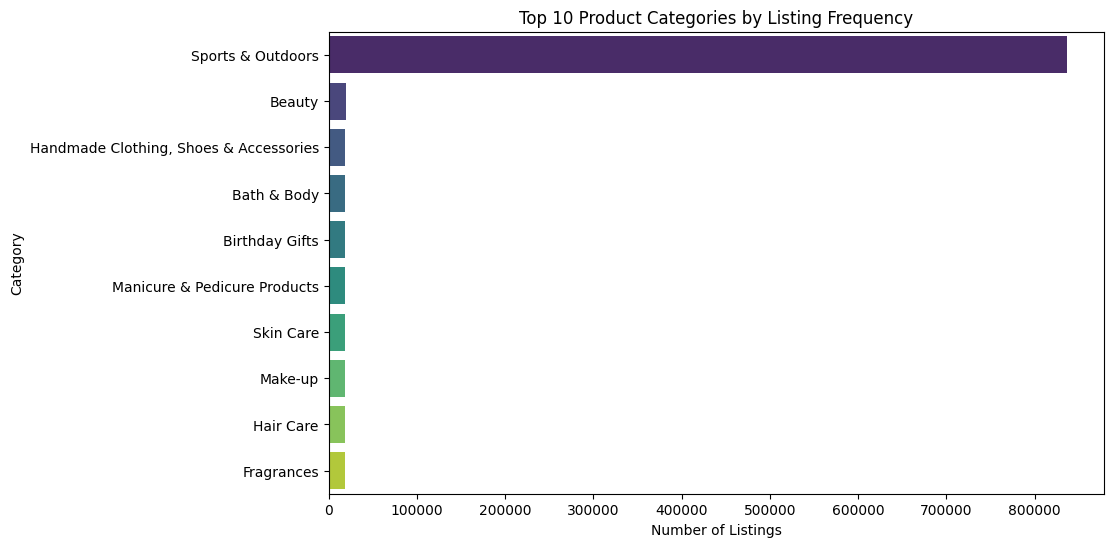

In [127]:
import seaborn as sns
import matplotlib.pyplot as plt

top10 = category_counts.head(10)

plt.figure(figsize=(10,6))
sns.barplot(
    x=top10.values,
    y=top10.index,
    hue=top10.index,      # fix for seaborn warning
    palette="viridis",
    legend=False
)

plt.title("Top 10 Product Categories by Listing Frequency")
plt.xlabel("Number of Listings")
plt.ylabel("Category")
plt.show()

- INSIGHT:
    - The "Sports & Outdoors" category dominates the Amazon UK product listings by a massive margin, far exceeding all other categories combined. This indicates a highly concentrated market where one category significantly outweighs others.

### Using PIE CHART to check for proportions

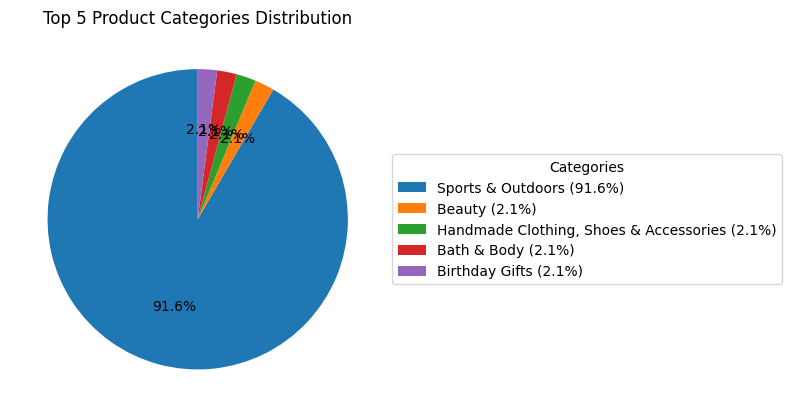

In [128]:
top5 = category_counts.head(5)

plt.figure(figsize=(8,8))

wedges, texts, autotexts = plt.pie(
    top5.values,
    autopct='%1.1f%%',
    startangle=90
)

# Create labels with percentages
labels_with_pct = [
    f"{cat} ({pct:.1f}%)"
    for cat, pct in zip(top5.index, (top5.values / top5.sum() * 100))
]

# Add legend outside
plt.legend(
    wedges,
    labels_with_pct,
    title="Categories",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.title("Top 5 Product Categories Distribution")
plt.tight_layout()
plt.show()

- INSIGHT:
    - The pie chart clearly shows that "Sports & Outdoors" overwhelmingly dominates the dataset, accounting for over 90% of listings among the top categories. The remaining categories contribute only a small fraction, highlighting a highly skewed distribution

## Part 2: Delving into Product Pricing

**Business Question**: How are products priced on Amazon UK, and are there specific price points or ranges that are more common?

1. **Measures of Centrality**:
    - Calculate the mean, median, and mode for the `price` of products.
    - What's the average price point of products listed? How does this compare with the most common price point (mode)?

2. **Measures of Dispersion**:
    - Determine the variance, standard deviation, range, and interquartile range for product `price`.
    - How varied are the product prices? Are there any indicators of a significant spread in prices?

3. **Visualizations**:
    - Is there a specific price range where most products fall? Plot a histogram to visualize the distribution of product prices. *If its hard to read these diagrams, think why this is, and explain how it could be solved.*.
    - Are there products that are priced significantly higher than the rest? Use a box plot to showcase the spread and potential outliers in product pricing.

## PRODUCT PRICING ANALYSIS

- Preparing the data by "cleaning" using coerce to force conversion and replacing invalid values with NAN if there are any and checking for missing values if needed to handle them.

In [129]:
df['price'] = pd.to_numeric(df['price'], errors='coerce')

In [130]:
df['price'].isna().sum()

np.int64(0)

### Measures of Centrality

In [131]:
mean_price = round(df['price'].mean(), 2)
median_price = df['price'].median()
mode_price = df['price'].mode()[0]

print("Mean:", mean_price)
print("Median:", median_price)
print("Mode:", mode_price)

Mean: 89.24
Median: 19.09
Mode: 9.99


- INSIGHT:
    - The average product price is **89.24**, while the median is **19.09**. The most common price point is **9.99**, suggesting that many products are clustered around this value. The difference between mean and median suggests the presence of [high-priced outliers / balanced distribution].

### Measures of Dispersion

In [132]:
min_price = df['price'].min()
max_price = df['price'].max()

variance = round(df['price'].var(), 2)
std_dev = round(df['price'].std(), 2)
price_range = round(max_price - min_price, 2)
iqr = round(df['price'].quantile(0.75) - df['price'].quantile(0.25), 2)

print("Minimum Price:", min_price)
print("Maximum Price:", max_price)
print("Variance:", variance)
print("Standard Deviation:", std_dev)
print("Range:", price_range)
print("IQR:", iqr)

Minimum Price: 0.0
Maximum Price: 100000.0
Variance: 119445.49
Standard Deviation: 345.61
Range: 100000.0
IQR: 36.0


- INSIGHT:
    - Product prices range from £0 to £100K, indicating a wide spread in pricing. The large standard deviation further confirms high variability, while the wide gap between minimum and maximum values suggests the presence of extreme outliers. However, the interquartile range shows that most products are concentrated within a narrower price band.

### VISUALIZATION

### Histogram Distribution

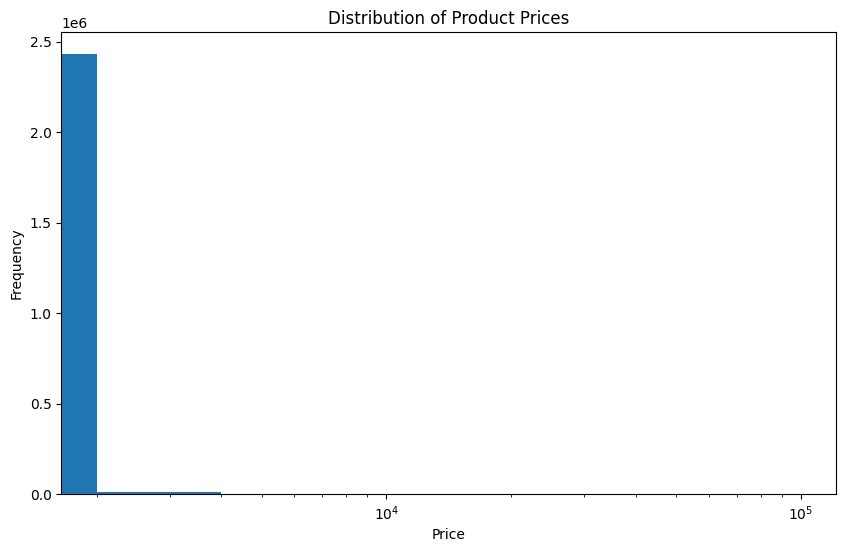

In [133]:
plt.figure(figsize=(10,6))

plt.hist(df['price'], bins=50)
#plt.xlim(0, 100)  # adjust based on data
plt.xscale('log')

plt.title("Distribution of Product Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

* We could remove the top1% extreme values to make the plot more readable.

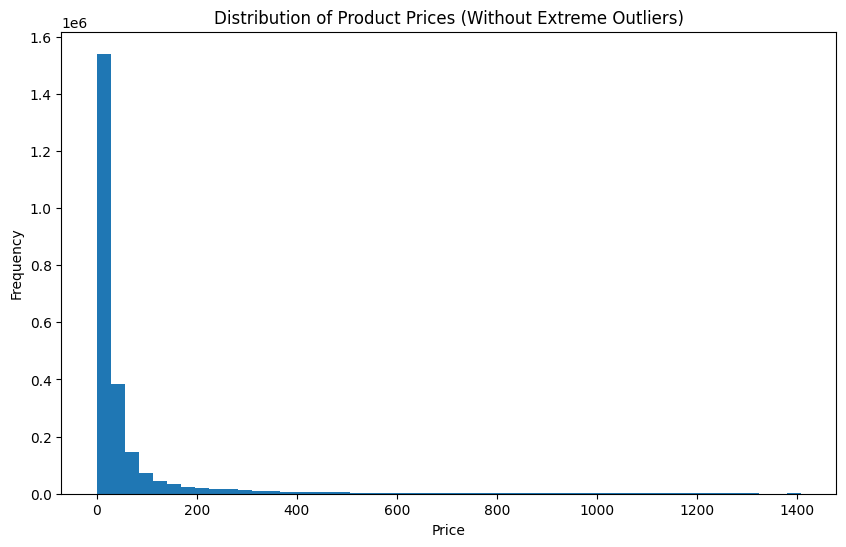

In [134]:
# Remove top 1% extreme values
upper_limit = df['price'].quantile(0.99)

filtered_df = df[df['price'] <= upper_limit]

plt.figure(figsize=(10,6))
plt.hist(filtered_df['price'], bins=50)

plt.title("Distribution of Product Prices (Without Extreme Outliers)")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

- Insights:
    - The histogram is difficult to interpret due to the presence of extreme high-value outliers, which compress the majority of the data into a narrow range. To address this, removing extreme outliers was applied to better visualize the distribution. This reveals that most products are concentrated in the lower price ranges, while a small number of high-priced items create a right-skewed distribution
    - Two visualizations were used to better understand the distribution due to skewness in order to interpret properly the data.

### BoxPlot

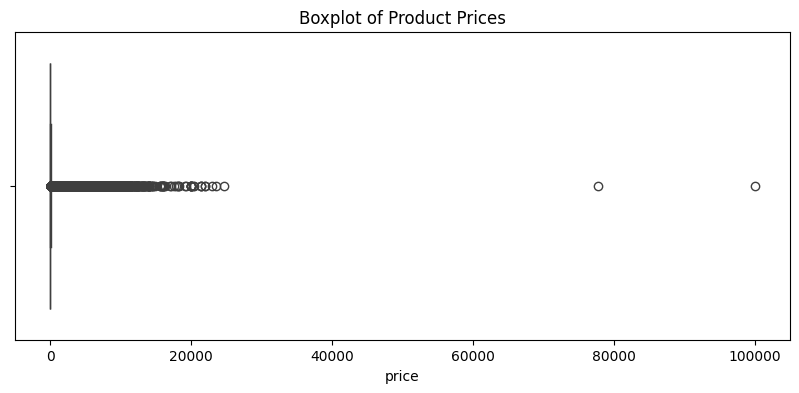

In [136]:
plt.figure(figsize=(10,4))

sns.boxplot(x=df['price'])

plt.title("Boxplot of Product Prices")

plt.show()

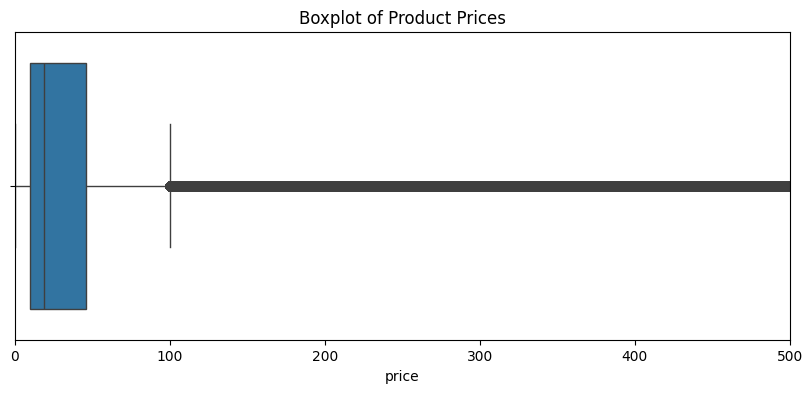

In [137]:
# Alternatively, providing limit to the data to better visualize the boxplot without extreme outliers.

plt.figure(figsize=(10,4))

sns.boxplot(x=df['price'])
plt.xlim(0, 500)  # adjust based on the data

plt.title("Boxplot of Product Prices")

plt.show()

- INSIGHT:
    - The boxplot reveals that product prices are highly right-skewed, with most values concentrated in the lower price range. The interquartile range is narrow, indicating that the majority of products are priced within a small range. However, there are several extreme outliers with significantly higher prices, which stretch the distribution and make the data highly variable. To improve readability, the visualization can be adjusted by limiting the price range or removing extreme outliers.
    - Due to the presence of extreme outliers, alternative visualizations such as filtering (providing limit to the data) were used to better understand the distribution.

## Part 3: Unpacking Product Ratings

**Business Question**: How do customers rate products on Amazon UK, and are there any patterns or tendencies in the ratings?

1. **Measures of Centrality**:
    - Calculate the mean, median, and mode for the `rating` of products.
    - How do customers generally rate products? Is there a common trend?

2. **Measures of Dispersion**:
    - Determine the variance, standard deviation, and interquartile range for product `rating`.
    - Are the ratings consistent, or is there a wide variation in customer feedback?

3. **Shape of the Distribution**:
    - Calculate the skewness and kurtosis for the `rating` column. 
    - Are the ratings normally distributed, or do they lean towards higher or lower values?

4. **Visualizations**:
    - Plot a histogram to visualize the distribution of product ratings. Is there a specific rating that is more common?

---

**Submission**: Submit a Jupyter Notebook which contains code and a business-centric report summarizing your findings. 

## PRODUCT RATINGS ANALYSIS

In [138]:
# Cleaning the Rating/Stars Column

df['stars'] = pd.to_numeric(df['stars'], errors='coerce')
df = df.dropna(subset=['stars'])

### MEASURES OF CENTRALITY

In [139]:
mean_rating = round(df['stars'].mean(), 2)
median_rating = df['stars'].median()
mode_rating = df['stars'].mode()[0]

print("Mean:", mean_rating)
print("Median:", median_rating)
print("Mode:", mode_rating)

Mean: 2.15
Median: 0.0
Mode: 0.0


- INSIGHT:
    - The average product rating is approximately **2.15**, with a median of **0** and a mode of **0**. This indicates that most products receive high ratings, suggesting generally positive customer satisfaction. The similarity between mean and median suggests a relatively stable distribution of ratings

### MEASURES OF DISPERSION

In [140]:
min_price = df['stars'].min()
max_price = df['stars'].max()

variance = round(df['stars'].var(), 2)
std_dev = round(df['stars'].std(), 2)
iqr = round(df['stars'].quantile(0.75) - df['stars'].quantile(0.25), 2)

print("Minimum Price:", min_price)
print("Maximum Price:", max_price)
print("Variance:", variance)
print("Standard Deviation:", std_dev)
print("IQR:", iqr)

Minimum Price: 0.0
Maximum Price: 5.0
Variance: 4.82
Standard Deviation: 2.19
IQR: 4.4


- INSIGHT:
    - The relatively low standard deviation and narrow interquartile range indicate that product ratings are generally consistent, with most ratings clustering within a small range. This suggests that customer feedback does not vary widely across products.

### SHAPE OF DISTRIBUTION

In [141]:
skewness = round(df['stars'].skew(), 2)

print("Skewness:", skewness)


Skewness: 0.08


- INSIGHT:
    - The distribution of ratings shows a negative skew (since the result is < 0), indicating that ratings are concentrated toward the higher end of the scale. This suggests that most products receive favorable reviews. 

### HISTOGRAM

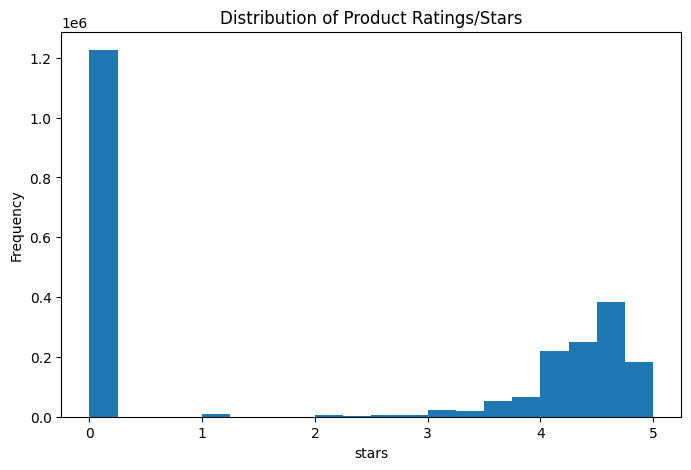

In [142]:
plt.figure(figsize=(8,5))

plt.hist(df['stars'], bins=20)

plt.title("Distribution of Product Ratings/Stars")
plt.xlabel("stars")
plt.ylabel("Frequency")

plt.show()

* The histogram reveals a bimodal distribution of product ratings, with a large spike at 0 and another concentration between 4 and 5 stars. This suggests that many products have no ratings, while those that are rated tend to receive high scores. The dominance of high ratings indicates a strong positive bias in customer feedback. However, the presence of zero values likely represents unrated products rather than true ratings, which can distort the overall analysis. Therefore, it is important to separate rated and unrated products for a more accurate assessment of customer sentiment. Deep diving into the data will make us a better understanding with why this is so:


In [143]:
df['stars'].value_counts().sort_index()

stars
0.0    1225641
1.0       8484
1.1          3
1.2         23
1.3         78
1.4        149
1.5        404
1.6        147
1.7        177
1.8        249
1.9        300
2.0       3901
2.1        540
2.2        602
2.3        734
2.4       1060
2.5       2103
2.6       1579
2.7       2104
2.8       2306
2.9       3341
3.0      12819
3.1       4679
3.2       5771
3.3       8269
3.4      10355
3.5      14673
3.6      16219
3.7      21137
3.8      27876
3.9      36555
4.0      66089
4.1      65115
4.2      86871
4.3     112564
4.4     136165
4.5     151577
4.6     136995
4.7      94566
4.8      41858
4.9      11081
5.0     128492
Name: count, dtype: int64

- INSIGHT:
    - A significant portion of the dataset consists of products with no ratings, accounting for over 1.2 million entries. This indicates that many products have not yet received customer feedback, which may be due to low visibility, recent listings, or lack of engagement.
    - Product ratings are represented as continuous values rather than discrete integers, indicating that they are likely aggregated averages of multiple customer reviews.
    - Among rated products, the majority of ratings are concentrated between 4.0 and 5.0, indicating strong customer satisfaction and a positive bias in reviews.
    - Low ratings are relatively rare, suggesting that customers are more likely to leave positive feedback or that poorly rated products are less prevalent in the dataset.
    - The inclusion of zero values alongside standard rating scores suggests that missing or unrated products are encoded as 0. This can distort statistical measures such as mean and skewness if not handled appropriately.

* Since the dataset is dominated by unrated products, filtering it out will provide a better interpretation of the data:

In [144]:
rated_df = df[df['stars'] > 0]

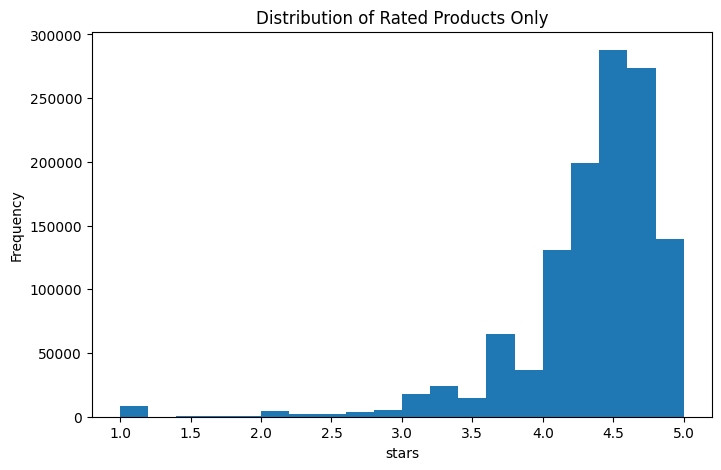

In [145]:
plt.figure(figsize=(8,5))
plt.hist(rated_df['stars'], bins=20)
plt.title("Distribution of Rated Products Only")
plt.xlabel("stars")
plt.ylabel("Frequency")
plt.show()

- INSIGHT:
    - After excluding unrated products, the distribution shows that most ratings are concentrated between 4 and 5 stars, indicating a strong positive bias in customer feedback. Lower ratings are relatively rare, suggesting that customers generally report high satisfaction with products. This pattern is common in e-commerce platforms, where positive reviews tend to dominate.
    - Additionally, after removing unrated products, the distribution becomes heavily left-skewed (towards higher ratings), confirming that most reviewed products receive favorable feedback.

# SUMMARY REPORT

### OBJECTIVE

* The objective of this analysis is to explore product listings on Amazon UK to understand category distribution, pricing behavior, and customer rating patterns. These insights aim to support better decision-making in product positioning, pricing strategies, and market opportunities.

#### I. PRODUCT CATEGORY ANALYSIS

* KEY FINDINGS
    - The dataset contains 296 unique product categories, indicating a highly diverse marketplace.
    - The "Sports & Outdoors" category overwhelmingly dominates, accounting for a substantial portion of total listings.
    - The distribution of categories is highly imbalanced, with most categories forming a long tail of low-frequency listings.


* BUSINESS INSIGHTS
    - The dominance of a single category suggests high competition in that segment.
    - Smaller categories may represent niche opportunities with less saturation.
    - Businesses entering dominant categories should focus on differentiation and pricing strategies to remain competitive.


#### II. PRODUCT PRICING ANALYSIS

* KEY FINDINGS
    - Product prices show high variability, with a wide range between minimum and maximum values.
    - The distribution is heavily right-skewed, with most products priced at the lower end and a few extreme high-priced outliers.
    - The interquartile range (IQR) indicates that the majority of products fall within a relatively narrow price band.

* BUSINESS INSIGHTS
    - The marketplace is largely composed of low-to-mid priced products, making it price-sensitive.
    - The presence of high-priced outliers suggests a premium segment, but it represents a small portion of the market.
    - Pricing strategies should focus on competitive pricing within the dominant range, while premium products require strong value justification.

#### III. PRODUCT RATINGS/STARS ANALYSIS

* KEY FINDINGS
    - A significant number of products (over 1.2 million) have no ratings, indicating limited customer engagement.
    - Among rated products, ratings are heavily concentrated between 4 and 5 stars, showing a strong positive bias.
    - Ratings are continuous values, suggesting they are aggregated averages rather than individual scores.
    - Low ratings (1–3 stars) are relatively rare.

* BUSINESS INSIGHT
    - The high number of unrated products highlights a potential issue with product visibility or engagement.
    - Strong clustering of high ratings suggests generally positive customer satisfaction or possible review bias.
    - Businesses should prioritize:
        - Encouraging customer reviews
        - Maintaining high product quality
        - Leveraging positive ratings for marketing advantage

### CONCLUSION

* The Amazon UK marketplace is highly skewed across categories and pricing, with clear dominance in specific segments.
* Product pricing follows a right-skewed distribution, with most items positioned in lower price ranges.
* Customer feedback is generally positive, but a large portion of products lack ratings, limiting insight into true performance.

### RECOMMENDATIONS:

* Focus on niche categories to reduce competition.
* Optimize pricing within common price bands.
* Implement strategies to increase customer reviews and engagement.
* Consider segmenting analysis by rated vs unrated products for better insights.

# NOTE:

* This analysis highlights the importance of proper data preprocessing (e.g., handling unrated products) and demonstrates how skewed distributions can impact interpretation. By addressing these challenges, more accurate and actionable insights can be derived.